# Random Forest Code Goes Here

Loading in the train and test data sets

In [1]:
import pandas as pd

train_df = pd.read_parquet("../data/train.parquet")
test_df = pd.read_parquet("../data/test.parquet")

print(train_df.head())
print(train_df.shape)

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0
(25000, 2)


In [2]:
#separating features and labels

X_train_text = train_df["text"]
y_train = train_df["label"]

X_test_text = test_df["text"]
y_test = test_df["label"]

In [3]:
from sklearn.model_selection import train_test_split

# split training data: 75% train, 25% validation
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_text,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

Use TF-IDF to evaluate importance of textual data 

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

# fit is only on training data 
X_train = vectorizer.fit_transform(X_train_text)

# transform validation and test
X_val = vectorizer.transform(X_val_text)
X_test = vectorizer.transform(X_test_text)

Training the Random Forest Model

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [6]:
from sklearn.metrics import accuracy_score, classification_report

val_pred = rf.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print(classification_report(y_val, val_pred))

Validation Accuracy: 0.84176
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      3125
           1       0.85      0.83      0.84      3125

    accuracy                           0.84      6250
   macro avg       0.84      0.84      0.84      6250
weighted avg       0.84      0.84      0.84      6250



Evaluating the performance

Now, let's test different tree values to evaluate the effect on performance.

In [7]:
trees = [50, 100, 200, 300]

train_acc = []
val_acc = []

for t in trees:

    rf = RandomForestClassifier(
        n_estimators=t,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    train_acc.append(rf.score(X_train, y_train))
    val_acc.append(rf.score(X_val, y_val))

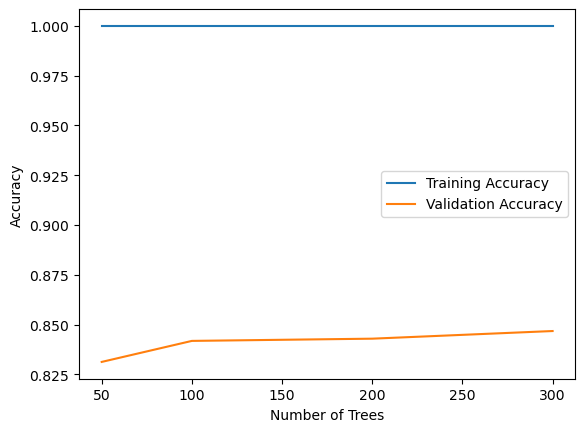

In [8]:
#plotting the trees to evaluate
import matplotlib.pyplot as plt

plt.plot(trees, train_acc, label="Training Accuracy")
plt.plot(trees, val_acc, label="Validation Accuracy")

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

The training accuracy remains at 1.0 across all values, showing that the model fits the training data perfectly. 

The testing accuracy increases slightly as the number of trees increases, but the improvement becomes smaller after around 100 trees. 

So, adding more trees improves stability but eventually the difference in accuracy is minimal.

In [9]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Test Accuracy: 0.84144
              precision    recall  f1-score   support

           0       0.83      0.86      0.84     12500
           1       0.85      0.83      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



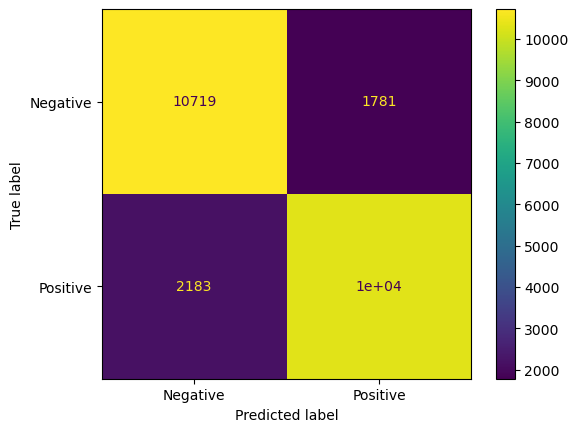

In [10]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.show()

True Negatives: 10719

False Positives: 1781

False Negatives: 2183

True Positives: 10317

The model struggles more with predicting positive reviews (shown by the higher number of False Negatives)

Feature Importance

In [11]:
feature_names = vectorizer.get_feature_names_out()

import numpy as np

importances = rf.feature_importances_
#top 20 most imp words
indices = np.argsort(importances)[::-1][:20]

top_words = feature_names[indices]
top_scores = importances[indices]

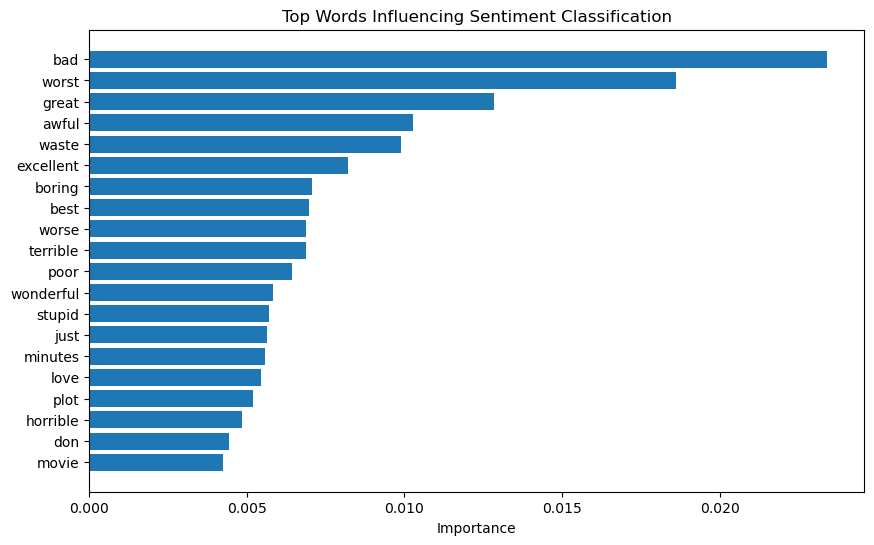

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_words[::-1], top_scores[::-1])

plt.xlabel("Importance")
plt.title("Top Words Influencing Sentiment Classification")

plt.show()

The most influential words: 

Negative sentiment words

- bad
- worst
- waste
- awful
- boring
- terrible
- stupid
- worse 
- poor 
- horrible

Positive sentiment words

- great
- excellent
- best 
- wonderful
- love 

This helps visualize why there was a greater number of False Negatives. The classifier relies heavily on strongly negative sentiment words like “bad”, “worst”, and “awful”. When positive reviews contained some negative language or criticism, the model might incorrectly classify them as negative.